The available variables and their data types:

First, we load the AmesHousing.csv dataset and use df.head() to check that it loaded correctly. This displays the first five rows and all columns.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


df.shape tells us how many rows and columns are available in the dataset.

In [2]:
df.shape

(2930, 82)

df.info() shows the columns in the dataset and their data types.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

The distribution of SalePrice:

The describe() function gives us descriptive statistics for SalePrice, such as the mean, standard deviation, minimum, maximum, and quartiles.

In [4]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

The histogram shows the distribution of SalePrice by displaying the number of houses within different price ranges.

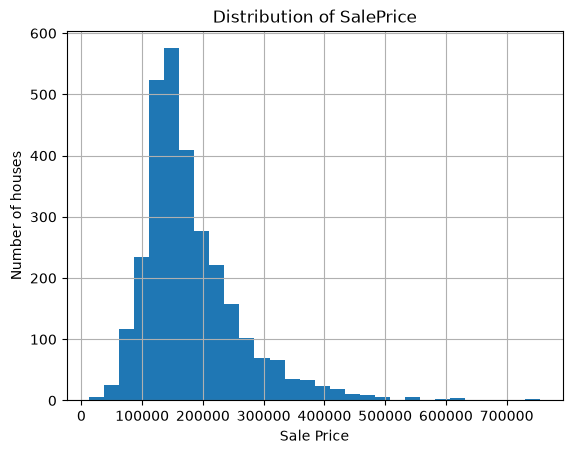

In [5]:
df["SalePrice"].hist(bins=30)

plt.xlabel("Sale Price")
plt.ylabel("Number of houses")
plt.title("Distribution of SalePrice")
plt.show()

The boxplot shows the distribution of SalePrice, including the median, quartiles, and possible outliers.

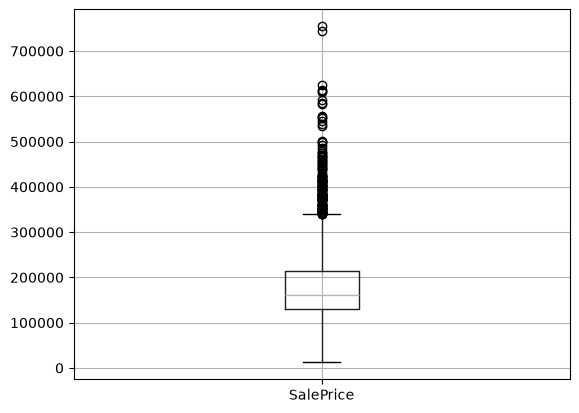

In [6]:
df.boxplot(column="SalePrice")
plt.show()

Missing values:

Here, we count the missing values in each column and use sort_values() to display the columns with the most missing values first.

In [7]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

Here, we calculate the percentage of missing values in each column and display the highest percentages first.

In [8]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent[missing_percent > 0].sort_values(ascending=False)

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Qual        5.426621
Garage Cond        5.426621
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Cond          2.730375
Bsmt Qual          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
BsmtFin SF 1       0.034130
BsmtFin SF 2       0.034130
Electrical         0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
Garage Area        0.034130
Garage Cars        0.034130
dtype: float64

Unusual values or patterns:

describe(include="object") is used to examine the categorical variables. It shows the number of values, unique values, most common value, and its frequency.

In [9]:
df.describe(include="object")

C:\Users\benja\AppData\Local\Temp\ipykernel_20540\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


Relationships that may be useful for predicting house prices:

Here, we calculate the correlation between the numerical variables and SalePrice and display the 10 variables with the highest positive correlation.

In [10]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()["SalePrice"].sort_values(ascending=False)

correlation.head(10)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Name: SalePrice, dtype: float64

This heatmap shows the correlations between eight variables that may be relevant for predicting SalePrice. Values closer to 1 indicate a stronger positive correlation, while values closer to -1 indicate a stronger negative correlation.

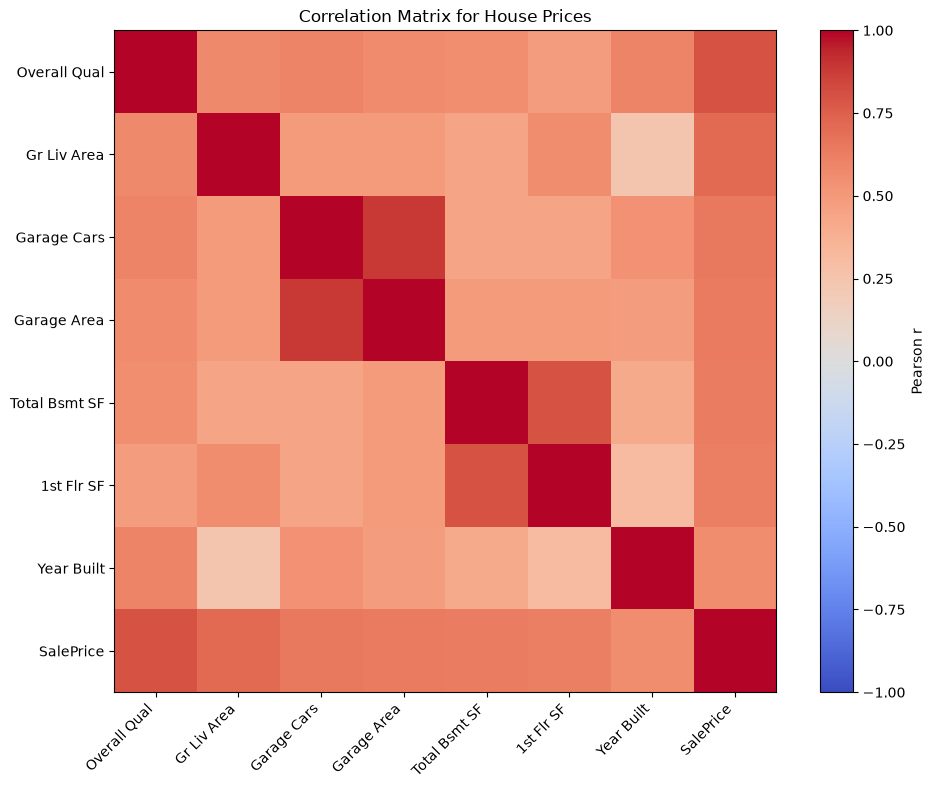

In [11]:
columns = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Garage Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "Year Built",
    "SalePrice"
]

corr = df[columns].corr()

plt.figure(figsize=(10, 8))

plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Pearson r")

plt.xticks(
    range(len(columns)),
    columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(columns)),
    columns
)

plt.title("Correlation Matrix for House Prices")
plt.tight_layout()
plt.show()